# Caltech Camera Traps — Exploratory Data Analysis

Visual companion to `reports/characterization.md`. Uses the same `src.data.characterize` functions the tests cover, so the numbers here match the report exactly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.data.loader import load_annotations
from src.data.characterize import class_distribution, metadata_survey, per_site_distribution

NON_SPECIES = {"empty", "car"}
ANNOTATIONS_PATH = Path.cwd().parent / "data" / "raw" / "caltech_images_20210113.json"

images, annotations, categories = load_annotations(ANNOTATIONS_PATH)
print(f"{len(images)} images, {len(annotations)} annotations, {images['location'].nunique()} sites")

243100 images, 245118 annotations, 140 sites


## Class distribution

Species counts, excluding non-species categories (`empty`, `car`).

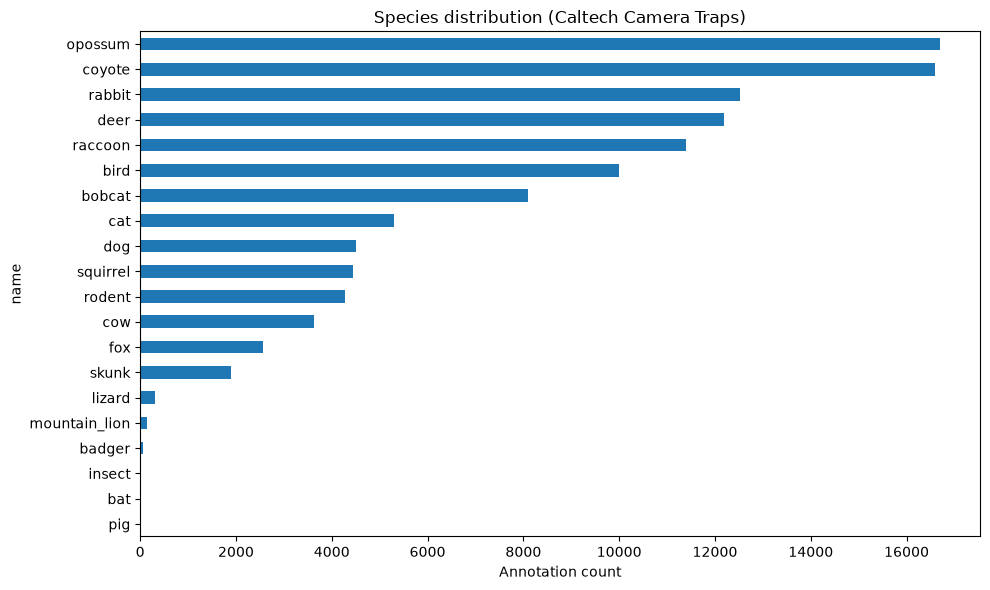

Imbalance ratio (majority/minority): 8349.0x


In [2]:
classes = class_distribution(annotations, categories, exclude=NON_SPECIES)

fig, ax = plt.subplots(figsize=(10, 6))
classes["count"].plot.barh(ax=ax)
ax.set_xlabel("Annotation count")
ax.set_title("Species distribution (Caltech Camera Traps)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (majority/minority): {classes['imbalance_ratio'].max():.1f}x")

## Per-site distribution

Species counts by camera location — the cross-site domain gap the design spec calls out. Showing the 15 highest-traffic sites for readability; the full 140-site table is in `reports/per_site_distribution.csv`.

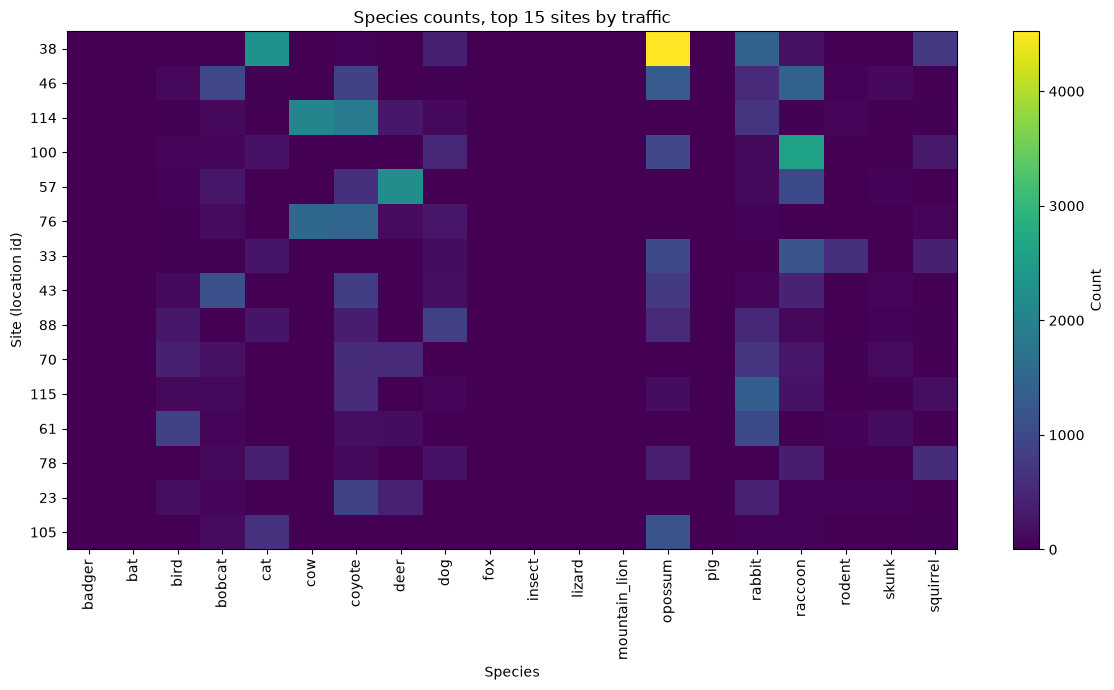

In [3]:
sites = per_site_distribution(images, annotations, categories, exclude=NON_SPECIES)
top_sites = sites.loc[sites.sum(axis=1).sort_values(ascending=False).head(15).index]

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(top_sites.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(top_sites.columns)))
ax.set_xticklabels(top_sites.columns, rotation=90)
ax.set_yticks(range(len(top_sites.index)))
ax.set_yticklabels(top_sites.index)
ax.set_xlabel("Species")
ax.set_ylabel("Site (location id)")
ax.set_title("Species counts, top 15 sites by traffic")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

## Metadata survey

Resolution mix and the day/night hour-of-day proxy (see docstring in `characterize.py` for why this is a proxy, not ground truth).

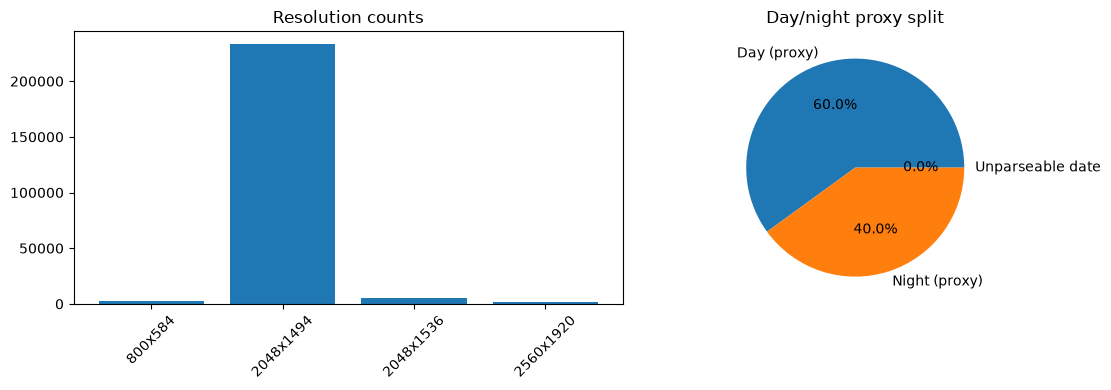

In [4]:
meta = metadata_survey(images)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

resolutions = {f"{w}x{h}": count for (h, w), count in meta["resolution_counts"].items()}
axes[0].bar(resolutions.keys(), resolutions.values())
axes[0].set_title("Resolution counts")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(
    [meta["day_count"], meta["night_count"], meta["unparseable_date_count"]],
    labels=["Day (proxy)", "Night (proxy)", "Unparseable date"],
    autopct="%1.1f%%",
)
axes[1].set_title("Day/night proxy split")

plt.tight_layout()
plt.show()

## Aspect ratio

Bucketed from the same width/height metadata used for resolution counts.

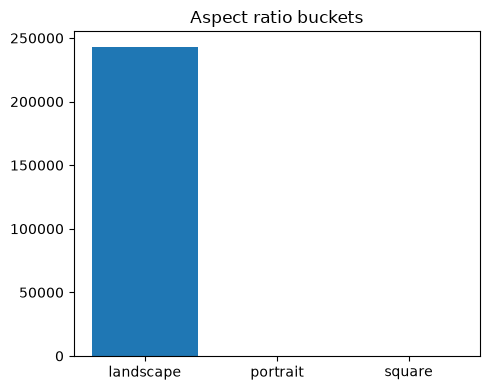

In [5]:
from src.data.characterize import aspect_ratio_survey

aspect = aspect_ratio_survey(images)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(aspect.keys(), aspect.values())
ax.set_title("Aspect ratio buckets")
plt.tight_layout()
plt.show()

## Image quality checks (sample)

Run on a stratified sample of real downloaded images (`data/raw/images/`, ~20 per category, not the full dataset) — annotations alone can't tell us about corruption, blur, or actual color content. See `reports/quality.md` for the full findings-and-recommendations writeup; this section is the visual companion.

In [6]:
from src.data.quality import blur_score, find_near_duplicates, is_corrupted, is_effectively_grayscale

IMAGES_DIR = Path.cwd().parent / "data" / "raw" / "images"
sample_paths = sorted(IMAGES_DIR.glob("*.jpg"))
corrupted = [p for p in sample_paths if is_corrupted(p)]
valid_paths = [p for p in sample_paths if p not in corrupted]
scores = {p: blur_score(p) for p in valid_paths}
print(f"{len(sample_paths)} sample images, {len(corrupted)} corrupted")

633 sample images, 0 corrupted


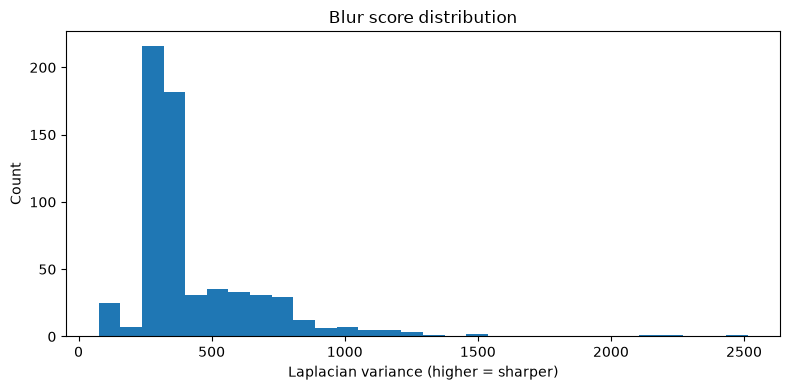

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(list(scores.values()), bins=30)
ax.set_xlabel("Laplacian variance (higher = sharper)")
ax.set_ylabel("Count")
ax.set_title("Blur score distribution")
plt.tight_layout()
plt.show()

Sharpest vs. blurriest images in the sample, side by side:

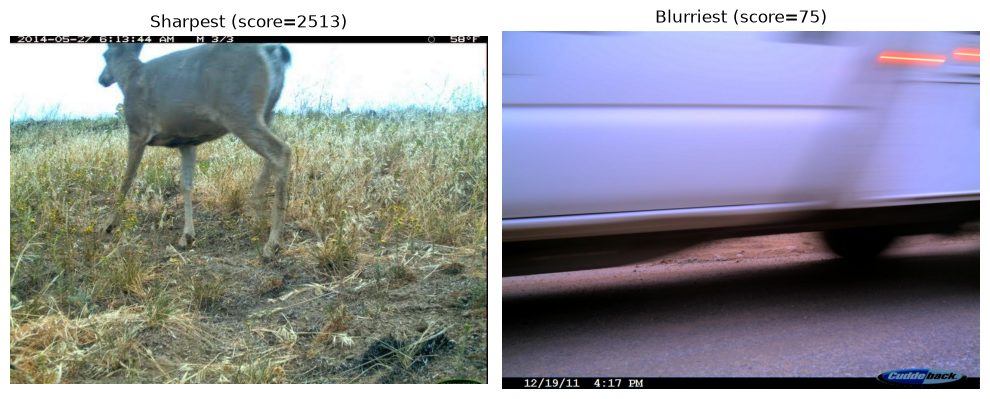

In [8]:
from PIL import Image as PILImage

sharpest = max(scores, key=scores.get)
blurriest = min(scores, key=scores.get)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(PILImage.open(sharpest))
axes[0].set_title(f"Sharpest (score={scores[sharpest]:.0f})")
axes[0].axis("off")
axes[1].imshow(PILImage.open(blurriest))
axes[1].set_title(f"Blurriest (score={scores[blurriest]:.0f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Pixel-based grayscale detection vs. the metadata hour-of-day proxy — see `reports/quality.md` for why these disagree and what to do about it:

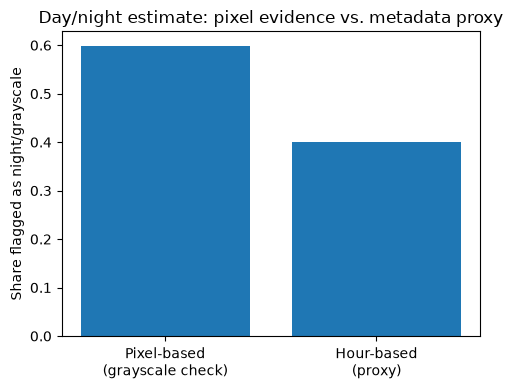

In [9]:
n_gray = sum(is_effectively_grayscale(p) for p in valid_paths)
pixel_gray_share = n_gray / len(valid_paths)
hour_proxy_night_share = meta["night_count"] / (meta["day_count"] + meta["night_count"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["Pixel-based\n(grayscale check)", "Hour-based\n(proxy)"],
    [pixel_gray_share, hour_proxy_night_share],
)
ax.set_ylabel("Share flagged as night/grayscale")
ax.set_title("Day/night estimate: pixel evidence vs. metadata proxy")
plt.tight_layout()
plt.show()

A near-duplicate pair caught by perceptual hashing (if any exist in this sample):

61 near-duplicate pairs found


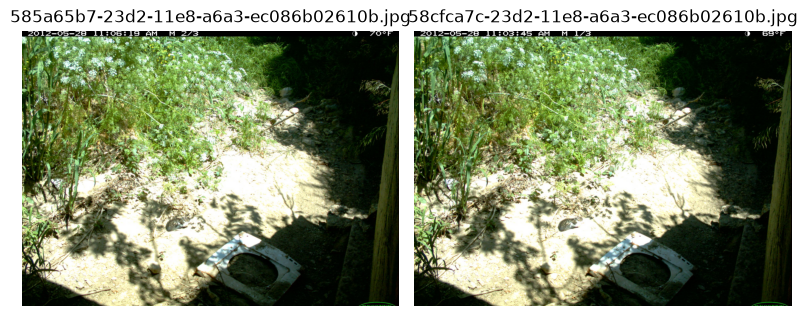

In [10]:
duplicates = find_near_duplicates(valid_paths)
print(f"{len(duplicates)} near-duplicate pairs found")

if duplicates:
    path_a, path_b = duplicates[0]
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(PILImage.open(path_a))
    axes[0].set_title(path_a.name)
    axes[0].axis("off")
    axes[1].imshow(PILImage.open(path_b))
    axes[1].set_title(path_b.name)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## Scale variation

Bounding-box area as a fraction of image area — how much of the frame the animal actually occupies, from `data/raw/caltech_bboxes_20200316.json` (a 63,025-image subset with bbox annotations, not the full dataset). See `reports/gap_analysis.md` for the full writeup.

In [11]:
import json
from src.data.characterize import bbox_area_ratio

BBOX_PATH = Path.cwd().parent / "data" / "raw" / "caltech_bboxes_20200316.json"
with open(BBOX_PATH) as bf:
    bbox_data = json.load(bf)
bboxes = pd.DataFrame(bbox_data["annotations"])
bbox_images = pd.DataFrame(bbox_data["images"])

ratios = bbox_area_ratio(bboxes, bbox_images)["area_ratio"]
print(f"median area ratio: {ratios.median():.3f}, "
      f"under 2% of frame: {100*(ratios < 0.02).mean():.1f}%")

median area ratio: 0.029, under 2% of frame: 33.6%


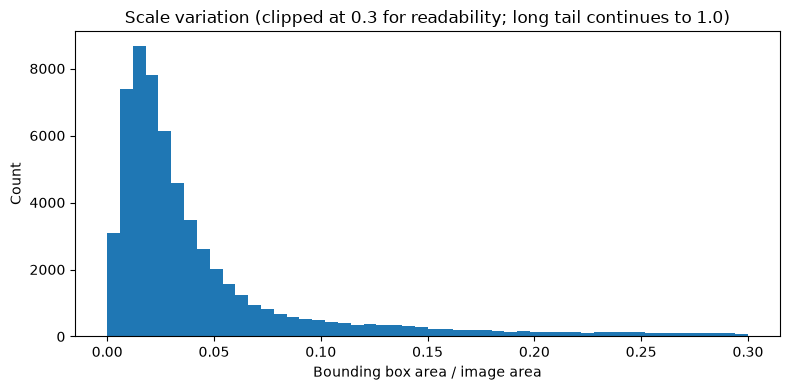

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios, bins=50, range=(0, 0.3))
ax.set_xlabel("Bounding box area / image area")
ax.set_ylabel("Count")
ax.set_title("Scale variation (clipped at 0.3 for readability; long tail continues to 1.0)")
plt.tight_layout()
plt.show()

## Occlusion — manual tagging tool

No reliable automatic proxy exists for occlusion without segmentation masks, so this is a deliberately manual, hands-on step (see the pair-programming decision behind this choice). **Run this section yourself in Jupyter**, not just read it:

1. Run the grid cell below to view a stratified batch of sample images.
2. For each filename shown, decide: `clear` (animal fully visible), `partial` (some occlusion — a branch, grass, partial frame cutoff), or `heavy` (animal mostly hidden).
3. Fill in the `occlusion_tags` dict in the cell after the grid with your judgments.
4. Run the save cell to persist your tags to `data/occlusion_tags.json`.
5. Re-run `python scripts/generate_gap_analysis_report.py` to fold your tags into the report.

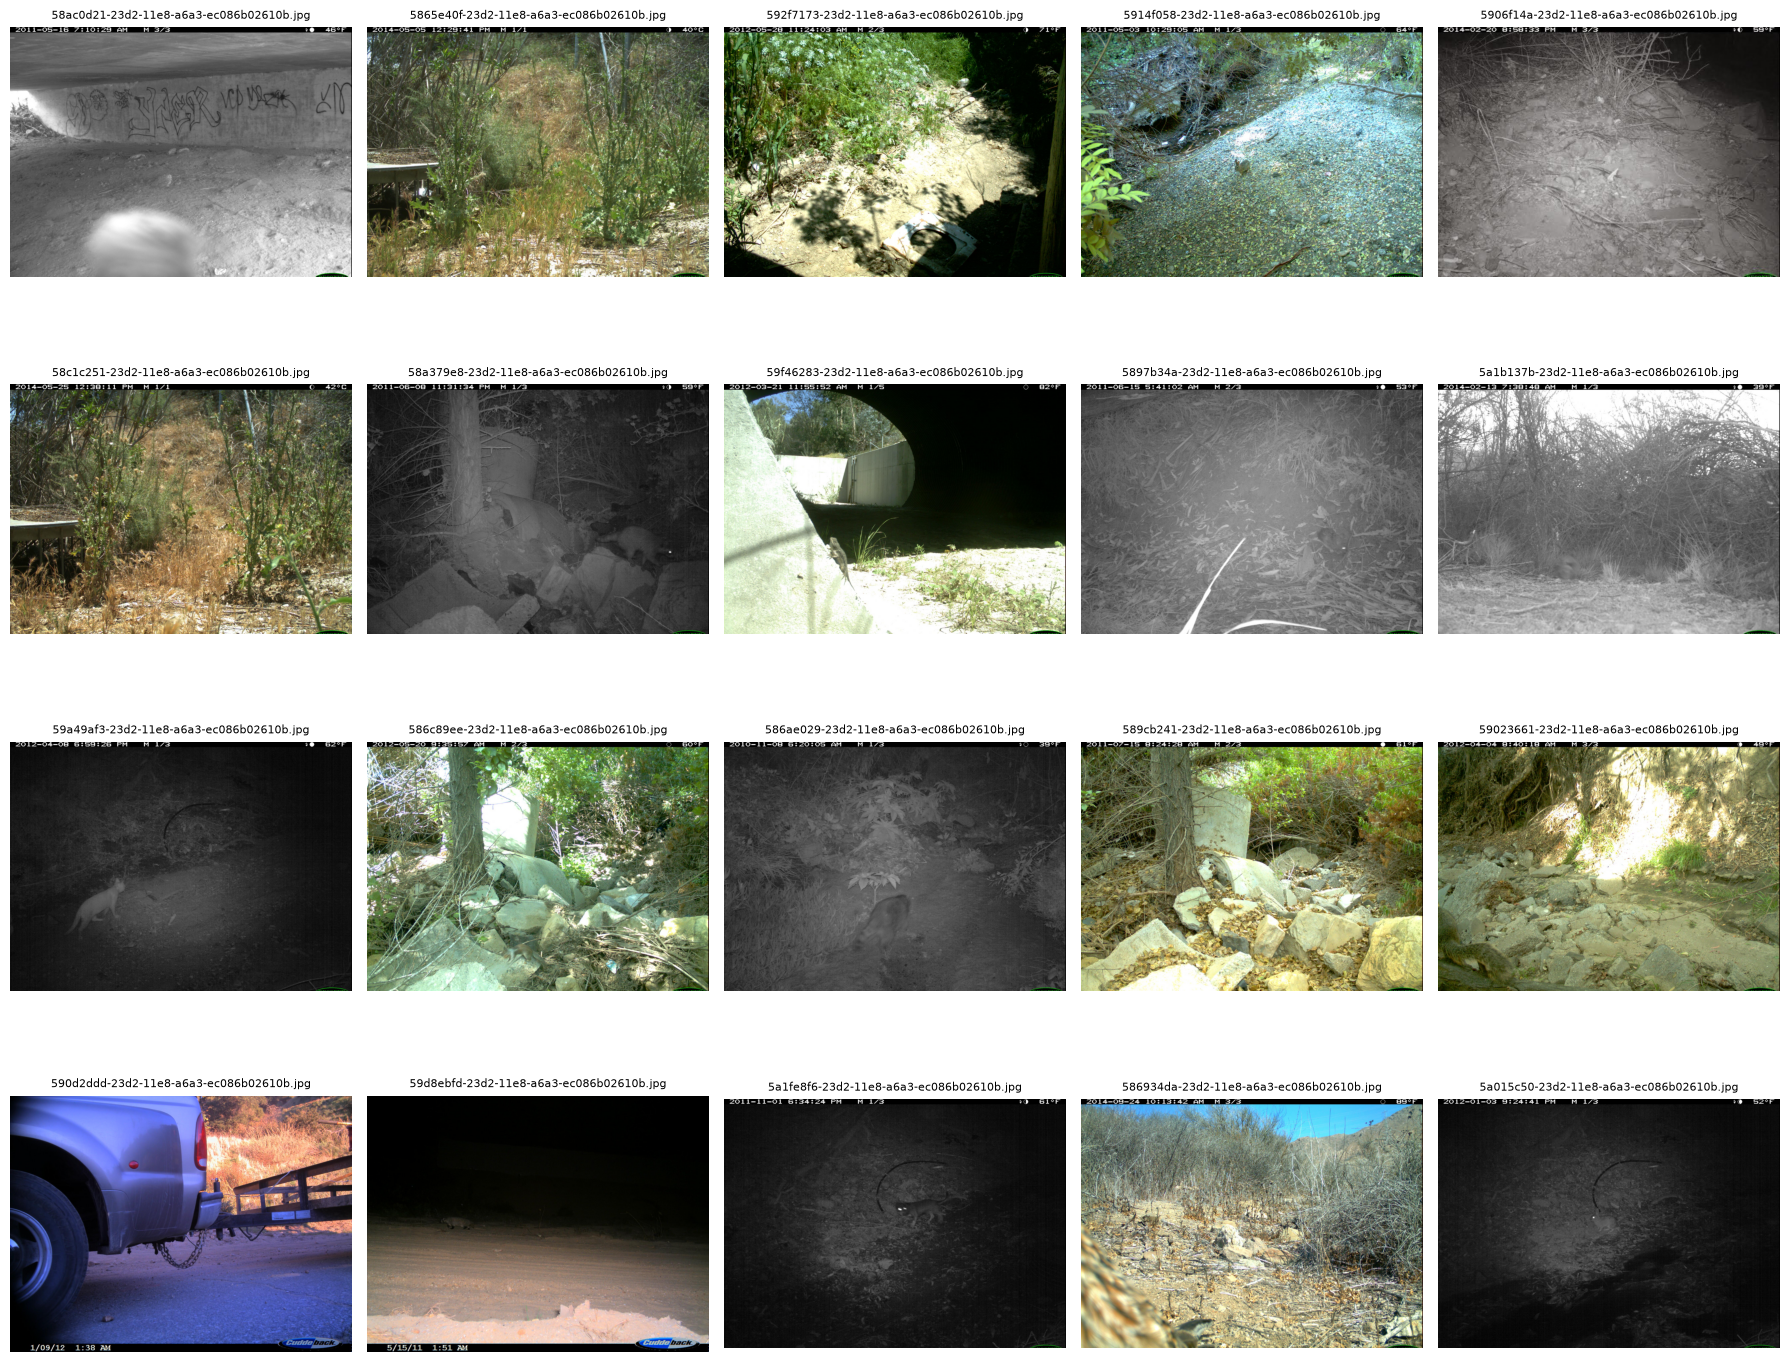

Filenames to tag:
  '58ac0d21-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '5865e40f-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '592f7173-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '5914f058-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '5906f14a-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '58c1c251-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '58a379e8-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '59f46283-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '5897b34a-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '5a1b137b-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '59a49af3-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '586c89ee-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear / partial / heavy
  '586ae029-23d2-11e8-a6a3-ec086b02610b.jpg': "",  # clear

In [13]:
import random

random.seed(42)
tagging_batch = random.sample(valid_paths, min(20, len(valid_paths)))

fig, axes = plt.subplots(4, 5, figsize=(18, 15))
for ax, path in zip(axes.flat, tagging_batch):
    ax.imshow(PILImage.open(path))
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Filenames to tag:")
for path in tagging_batch:
    print(f"  {path.name!r}: \"\",  # clear / partial / heavy")

In [14]:
# Fill this in by hand after looking at the grid above -- replace with your own judgments.
# This is intentionally left empty here; running it as-is produces no tags, which is
# correct until you've actually done the visual inspection.
occlusion_tags = {
    # "5968c0f9-23d2-11e8-a6a3-ec086b02610b.jpg": "clear",
    # "5998cfa4-23d2-11e8-a6a3-ec086b02610b.jpg": "partial",
}

if occlusion_tags:
    print(pd.Series(occlusion_tags).value_counts())
else:
    print("No tags recorded yet -- fill in occlusion_tags above after reviewing the grid.")

No tags recorded yet -- fill in occlusion_tags above after reviewing the grid.


In [15]:
OCCLUSION_TAGS_PATH = Path.cwd().parent / "data" / "occlusion_tags.json"

if occlusion_tags:
    with open(OCCLUSION_TAGS_PATH, "w") as tf:
        json.dump(occlusion_tags, tf, indent=2)
    print(f"Saved {len(occlusion_tags)} tags to {OCCLUSION_TAGS_PATH}")
else:
    print("Nothing to save -- occlusion_tags is empty.")

Nothing to save -- occlusion_tags is empty.


## Augmentation outputs

Before/after examples using the actual training transform pipeline (`src.data.augmentation.build_train_transform`).

In [16]:
import torch
from src.data.augmentation import build_train_transform, minority_species

aug_minority = minority_species(classes["count"])
print(f"{len(aug_minority)} of {len(classes)} species are minority class")

10 of 20 species are minority class


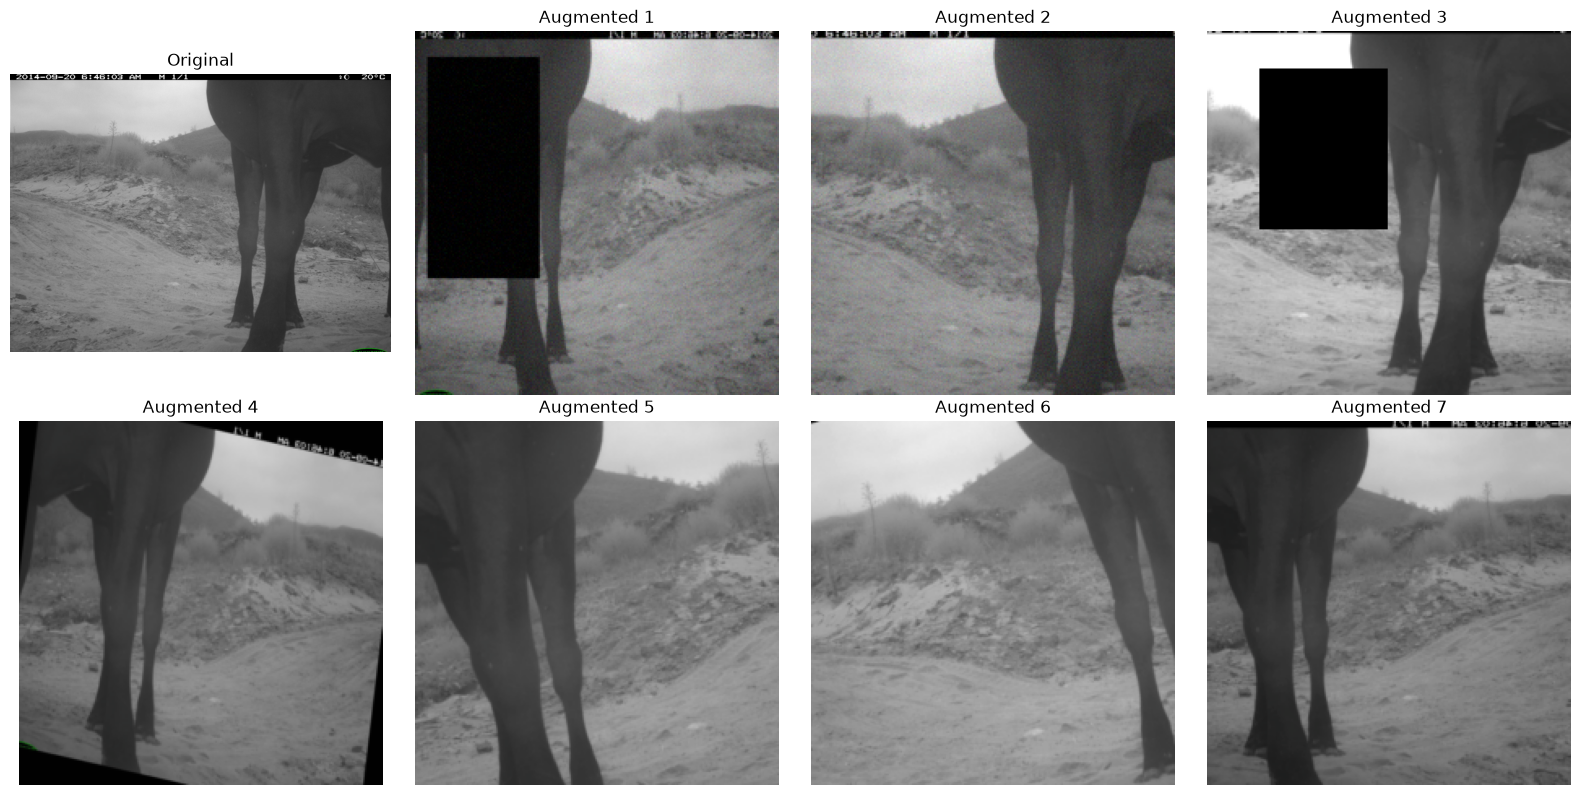

In [17]:
aug_sample_path = valid_paths[0]
aug_original = PILImage.open(aug_sample_path)

aug_train_transform = build_train_transform(is_minority=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(aug_original)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for i in range(1, 8):
    ax = axes.flat[i]
    augmented = aug_train_transform(aug_original)
    denorm = augmented * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) \
        + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    ax.imshow(denorm.clamp(0, 1).permute(1, 2, 0).numpy())
    ax.set_title(f"Augmented {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Majority vs. minority: differential augmentation probability

Same source image run through both pipeline variants, holding the random seed fixed so any visual difference comes from the probability/parameter table (spec section 2), not from random chance.

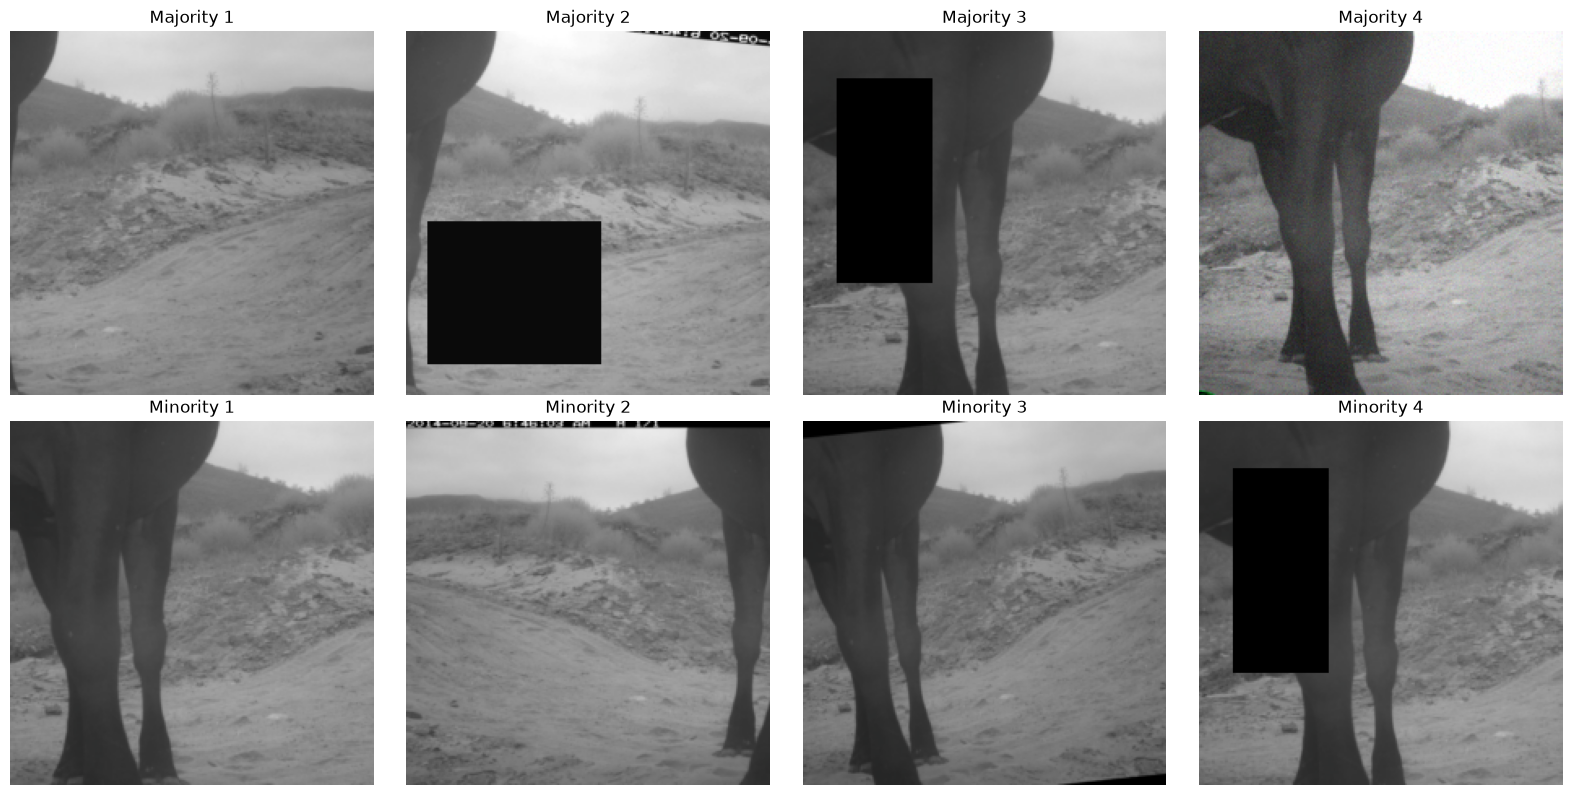

In [18]:
aug_train_transform_minority = build_train_transform(is_minority=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (label, transform) in enumerate(
    [("Majority", aug_train_transform), ("Minority", aug_train_transform_minority)]
):
    torch.manual_seed(0)
    for col in range(4):
        ax = axes[row, col]
        augmented = transform(aug_original)
        denorm = augmented * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) \
            + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        ax.imshow(denorm.clamp(0, 1).permute(1, 2, 0).numpy())
        ax.set_title(f"{label} {col + 1}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Oversampling effect on effective class balance

Raw annotation counts vs. the expected number of times each species is drawn per epoch under a `WeightedRandomSampler` built from `build_sample_weights` — the mechanism that actually balances effective training-set size (spec section 2, distinct from the per-step augmentation probabilities above).

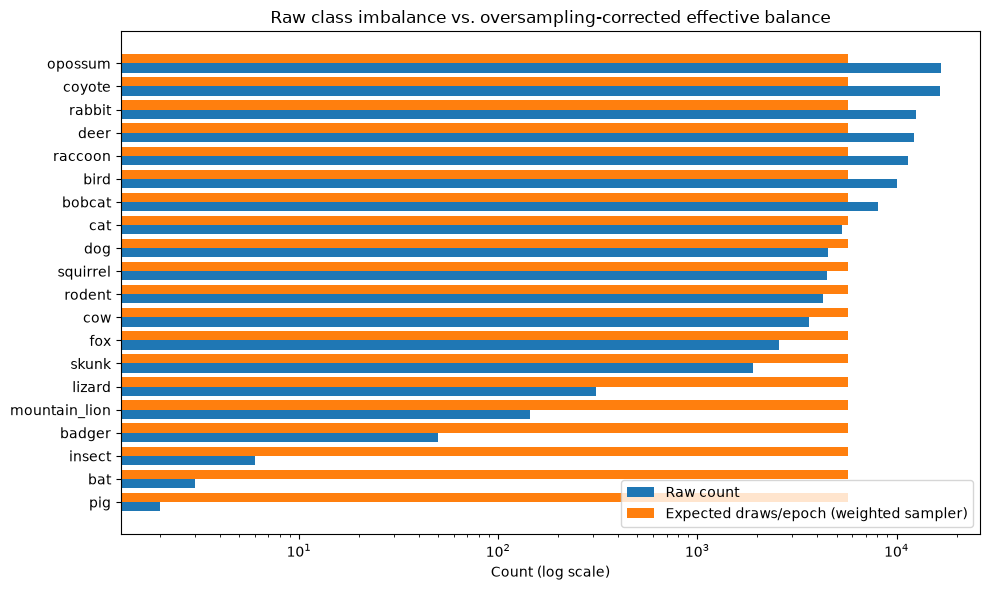

In [19]:
from src.data.augmentation import build_sample_weights

counts = classes["count"]
labels = pd.Series(counts.index.repeat(counts.values))
weights = pd.Series(build_sample_weights(labels, counts), index=labels.index)

total_weight = weights.sum()
total_samples = len(labels)
expected_draws = (
    pd.DataFrame({"label": labels, "weight": weights})
    .groupby("label")["weight"]
    .sum()
    .div(total_weight)
    .mul(total_samples)
)

comparison = pd.DataFrame({"raw_count": counts, "expected_draws_per_epoch": expected_draws})
comparison = comparison.sort_values("raw_count")

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(comparison))
ax.barh(x, comparison["raw_count"], height=0.4, label="Raw count", align="edge")
ax.barh([i + 0.4 for i in x], comparison["expected_draws_per_epoch"], height=0.4,
        label="Expected draws/epoch (weighted sampler)", align="edge")
ax.set_yticks([i + 0.4 for i in x])
ax.set_yticklabels(comparison.index)
ax.set_xscale("log")
ax.set_xlabel("Count (log scale)")
ax.set_title("Raw class imbalance vs. oversampling-corrected effective balance")
ax.legend()
plt.tight_layout()
plt.show()